# Convolutional Neural Network (CNN) for Image Clasification with pyTorch

Classification of the [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset

TODO: reproducibility

In [1]:
import numpy as np
from PIL import Image

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [3]:
import utils

In [4]:
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)['cnn']

# frequently used params

utils.print_params(params)

num_workers: 2
batch_size: 32
random_state: 42
ly_conv1_out: 12
ly_conv1_kernel: 5
ly_pool_kernel: 2
ly_conv2_out: 24
ly_conv2_kernel: 5
ly_fc1_out: 120
ly_fc2_out: 84
learning_rate: 0.001
momentum: 0.9
epochs: 30
model_file: data/trained/cnn_cifar10.pth


In [5]:
# reproducibility
#https://docs.pytorch.org/docs/stable/notes/randomness.html
foo = torch.manual_seed(params['random_state'])

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),  # scale to [0., 1.]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # shift to [-1.., 1.]
])

## Dataset

### Load

In [7]:
train_data = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)  # , align=False)
test_data = torchvision.datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)  # , align=False)

c:\dev\projects\deep_dish\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [8]:
# shuffle=True for reproducibility
train_loader = torch.utils.data.DataLoader(train_data, batch_size=params['batch_size'], shuffle=True, num_workers=params['num_workers'])
test_loader = torch.utils.data.DataLoader(test_data, batch_size=params['batch_size'], shuffle=True, num_workers=params['num_workers'])

### Prepare

In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
image, label = train_data[100]

(32, 32, 3)
ship


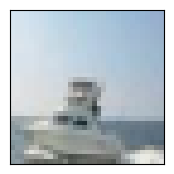

In [11]:
# manual rescale
arr = ((image.numpy() + 1)  * 255. / 2.).astype(np.uint8)
arr = np.rollaxis(arr,0,3)
print(arr.shape)

utils.imshow(arr)
print(class_names[label])

# Show in a separate window
#Image.fromarray(arr, 'RGB').show()


In [12]:
len(train_data), image.shape, image.min(), image.max(), label

(50000, torch.Size([3, 32, 32]), tensor(-0.7647), tensor(0.8980), 8)

## Model

### Build (architecture)

In [13]:
class CNNNet(nn.Module):

    def __init__(self):
        super(CNNNet, self).__init__()

        # w and h: floor((input=32 - kernel=5) / stride=1) + 1 = 28
        self.conv1 = nn.Conv2d(3, 12, 5)  # output shape (12, w, h)
        self.pool = nn.MaxPool2d(2, 2)  # output shape (12, 14, 14)
        # w and h: floor((input=14 - kernel=5) / stride=1) + 1 = 10
        self.conv2 = nn.Conv2d(12, 24, 5)  # output shape (12, 10, 10), pool again -> (24, 5, 5)
        self.fc1 = nn.Linear(24 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [14]:
model = CNNNet()

### Compile

In [15]:
loss_function = nn.CrossEntropyLoss()  # a.k.a. criterion

In [16]:
optimizer = optim.SGD(
    model.parameters(), lr=params['learning_rate'], momentum=params['momentum']
)

#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=params['learning_rate'],
#    momentum=params['momentum'],
#    weight_decay=1e-4,  # L2 regularization built-in
#    nesterov=True
#)

### Training loop (fit)

Or GOTO "Load"

In [ ]:
# for plotting
losses = []

for epoch in range(params['epochs']):

    model.train()
    running_loss = 0.0

    for i, data in enumerate(train_loader):
        X_batch, y_batch = data

        optimizer.zero_grad()

        preds = model(X_batch)

        ## y_batch.shape = [len_batch, 1] i.e., is a tensor([[1.], ... [8.]])
        ## preds.shape = [len_batch, 10]
        loss = loss_function(preds, y_batch.squeeze(-1).long())

        loss.backward()  # backpropagation
        optimizer.step()

        running_loss += loss.item()

    av_loss = running_loss / len(train_loader)  # average batch loss
    losses.append(av_loss)
    print(f"Epoch {epoch+1}/{params['epochs']}: Loss was {av_loss}")

In [ ]:
ax = utils.plot_train_losses(params['epochs'], losses)

### Save

In [ ]:
torch.save(model.state_dict(), params['model_file'])
print(f"Saved to {params['model_file']}")

### Load

In [17]:
model = CNNNet()
model.load_state_dict(torch.load(params['model_file']))

<All keys matched successfully>

## Results

### Predictions

New images, not in test set, not 32 $\times$ 32

In [18]:
new_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [19]:
def load_image(image_path):
    image = Image.open(image_path)
    image = new_transform(image)
#    image = image.unsqueeze(0)

    return image

In [20]:
from pathlib import Path

dir_path = Path("./data/images/cifar10_ext")
files = [p for p in dir_path.iterdir() if p.is_file()]
images = [load_image(f) for f in files]


(32, 32, 3)


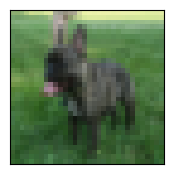

In [21]:
# manual rescale
arr = ((images[1].numpy() + 1)  * 255. / 2.).astype(np.uint8)  # TODO: why [0]?
arr = np.rollaxis(arr,0,3)
print(arr.shape)

utils.imshow(arr)

In [22]:
with torch.no_grad():
    model.eval()

    for i, image in enumerate(images):
        preds = model(image.unsqueeze(0))
        _, predicted = torch.max(preds, 1)
        print(f"Prediction {files[i]}: {class_names[predicted.item()]}")

Prediction data\images\cifar10_ext\french-bulldog-00.jpg: horse
Prediction data\images\cifar10_ext\french-bulldog-01.jpg: horse
Prediction data\images\cifar10_ext\french-bulldog-02.jpg: airplane
Prediction data\images\cifar10_ext\french-bulldog-03.jpg: horse
Prediction data\images\cifar10_ext\french-bulldog-04.jpg: horse


### Evaluation (accuracy)

In [23]:
total = 0  #XXX
correct = 0  #XXX

# TODO: better
all_predicted = []
all_y_test = []

with torch.no_grad():
    model.eval()  # evaluation mode

    for i, data in enumerate(test_loader):
        X_batch, y_batch = data
        preds = model(X_batch)
        _, predicted = torch.max(preds, 1)  # predicted labels
        total += y_batch.size(0)  #XXX
        correct += (predicted == y_batch).sum().item()  #XXX

        # TODO: list of tensors -> tensor
#        all_y_test += list(y_batch)
#        all_predicted += list(predicted)
        all_y_test += y_batch
        all_predicted += predicted

        if (i+1) % 50 == 0:
            print(f"{i+1}/{len(test_loader)} batches done", end="\r")

all_predicted = torch.tensor(all_predicted)
all_y_test = torch.tensor(all_y_test)
equals = (all_y_test == all_predicted)

test_acc = (equals.sum() / len(all_y_test)).item()
#test_acc = correct / total  #XXX

print(f"Test accuracy: {test_acc:.2%}")

Test accuracy: 69.26%


In [24]:
neqs = ~equals
neqs = np.where(neqs)[0]
len(neqs)

3074

In [25]:
neqs

array([   3,    7,   10, ..., 9984, 9997, 9998], shape=(3074,))

# -------- WIP --------

In [26]:
test_images = []

with torch.no_grad():
    model.eval()  # evaluation mode

    for i, data in enumerate(test_loader):
        X_batch, _ = data
        test_images += X_batch

#test_images = torch.tensor(test_images)

In [27]:
test_images[0].shape

torch.Size([3, 32, 32])

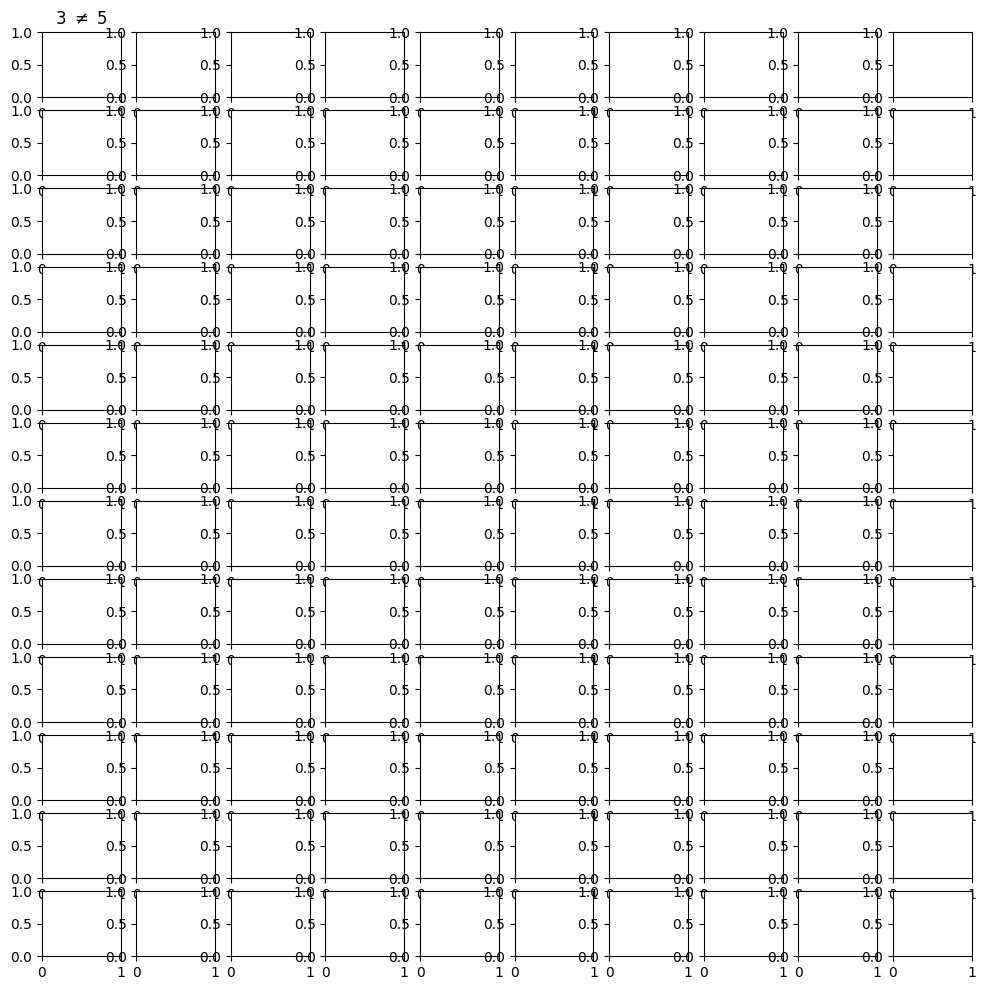

In [28]:
foo = utils.plot_wrong_mnist(test_images, all_predicted, all_y_test, neqs, img_width=32, img_height=32)

In [ ]:
all_y_test.squeeze(-1).long()

In [ ]:
all_predicted

In [ ]:
# lists of predicted digits
pred = preds.argmax(dim=1)
real = all_y_test.squeeze(-1).long()

In [ ]:
all_y_test = all_predicted

In [ ]:
#torch.stack(list_of_tensors, dim=0)
#torch.cat(list_of_tensors, dim=0)
#torch.tensor(list_of_tensors)

In [ ]:
#torch.stack(all_predicted, dim=0)
torch.tensor(all_predicted)

#all_predicted[0].shape
#all_predicted
#all_y_test

In [ ]:
predicted == y_batch

In [ ]:
preds[:1]

In [ ]:
a, b = torch.max(preds[:1], 0)

In [ ]:
a

In [ ]:
b

In [ ]:
torch.max?

### Show

In [ ]:
# code here

Plot wrongs